<a href="https://colab.research.google.com/github/ravi1563/FYP-RAVI/blob/main/Updated_Hypertuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



1.   https://www.kaggle.com/datasets/sukhmandeepsinghbrar/heart-attack-dataset
2.   https://data.mendeley.com/datasets/wmhctcrt5v/1




# **Loading Library Files**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
sns.set(style="whitegrid")

# **Loading Dataset**

In [3]:
df = pd.read_csv("Medicaldataset.csv")

# display first rows
df.head()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


# **Exploratory Data Analysis**

## **Shape of Dataset**

In [5]:
# shape of dataset
df.shape

# column names
df.columns

# dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


## **Checking Missing Values**

In [6]:
# missing values
df.isnull().sum()

,0
Age,0
Gender,0
Heart rate,0
Systolic blood pressure,0
Diastolic blood pressure,0
Blood sugar,0
CK-MB,0
Troponin,0
Result,0


## **Descriptive Statistical Analysis**

In [7]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


## **Target Distribution Graph**

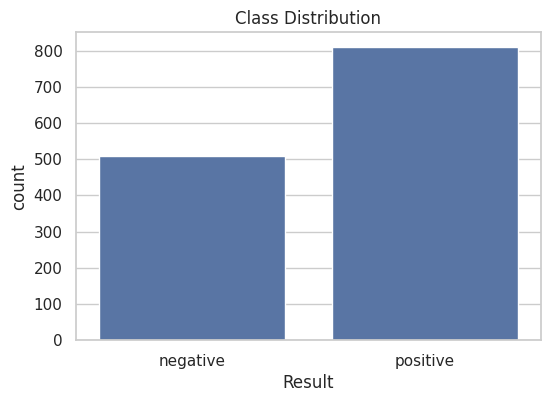

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Result', data=df)
plt.title("Class Distribution")
plt.show()

## **Numerical Distribution Graph**

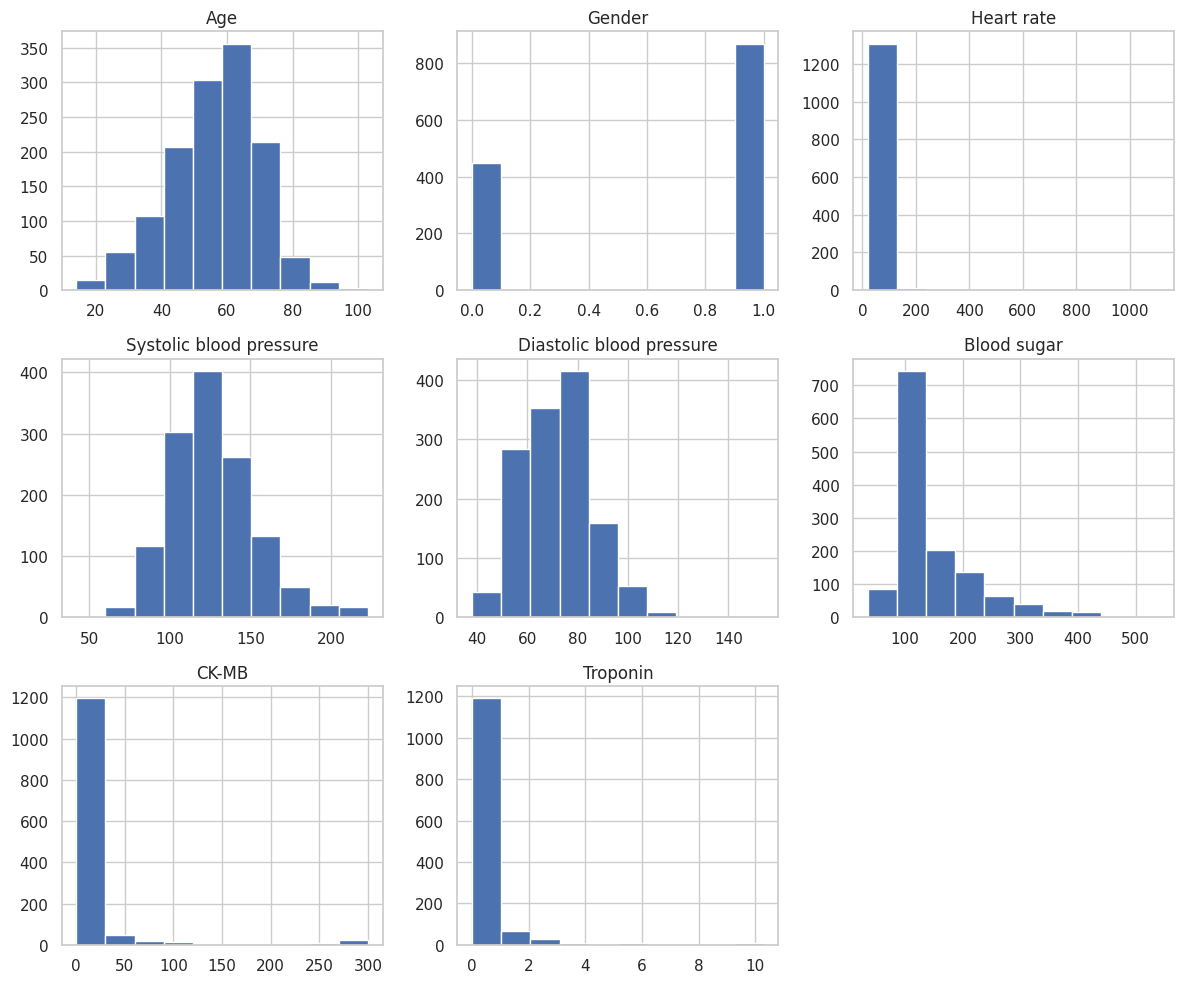

In [9]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## **Correlation Heatmap**

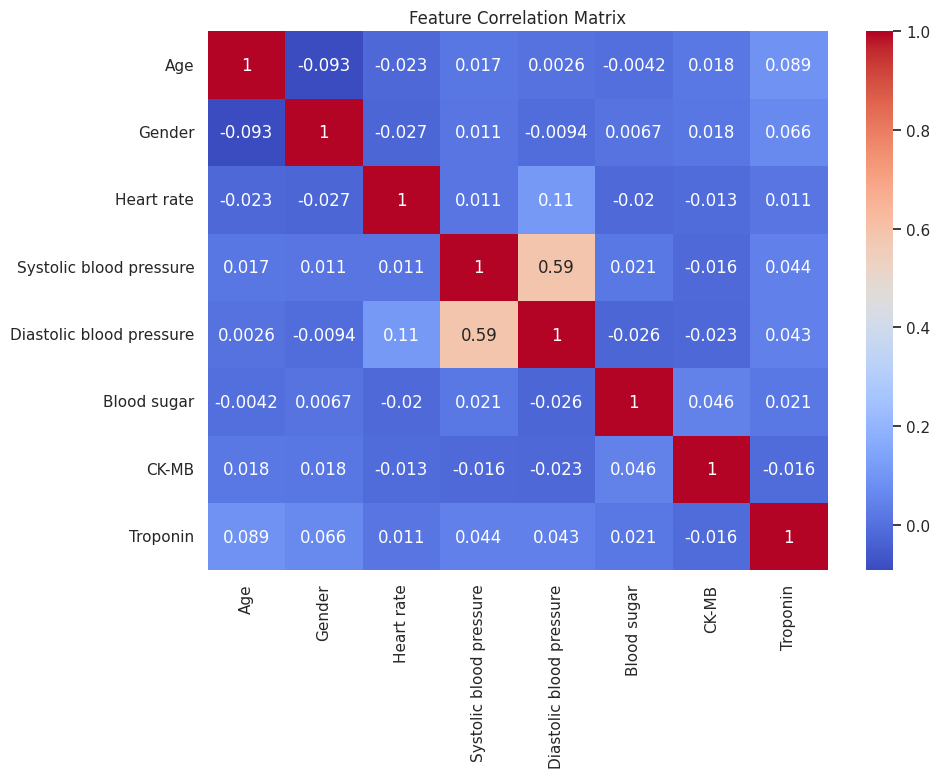

In [10]:
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## **Box plot to detect Outliers**

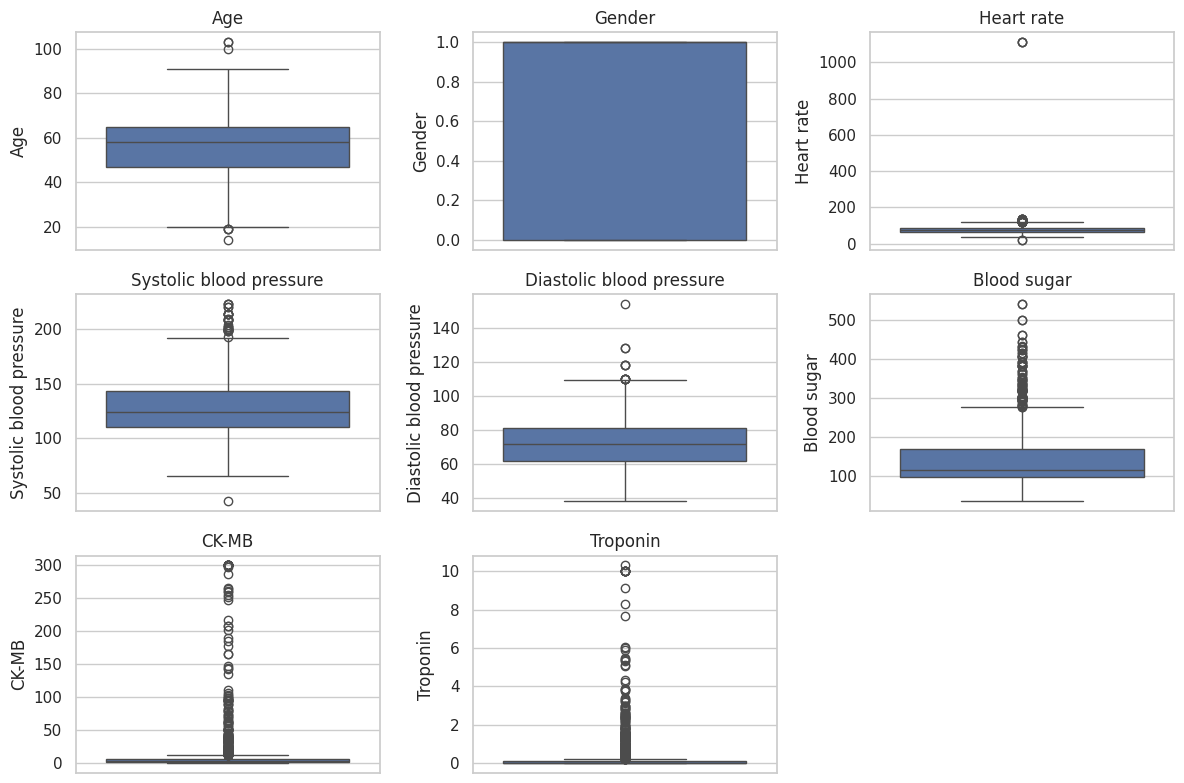

In [11]:
plt.figure(figsize=(12,8))

for i, col in enumerate(df.select_dtypes(include=np.number).columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Handle missing values (if any)
df = df.dropna()

# Encode categorical variables
label_encoder = LabelEncoder()

# Encode Gender
df['Gender'] = label_encoder.fit_transform(df['Gender'])

# Encode target variable if it is categorical
df['Result'] = label_encoder.fit_transform(df['Result'])

# Define features and target
X = df.drop('Result', axis=1)
y = df['Result']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling (important for Logistic Regression and SVM)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display dataset shapes
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (1055, 8)
Testing set: (264, 8)


# **Training Models**

In [13]:
# ===============================
# MODEL EVALUATION METRICS
# ===============================

import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

results = []

# Initialize models
log_reg = LogisticRegression(random_state=42)
svm_model = SVC(random_state=42, probability=True) # probability=True for ROC curve
rf_model = RandomForestClassifier(random_state=42)

models = {
    "Logistic Regression": (log_reg, X_train_scaled, X_test_scaled),
    "SVM": (svm_model, X_train_scaled, X_test_scaled),
    "Random Forest": (rf_model, X_train, X_test)
}

for name, (model, X_tr, X_te) in models.items():

    # Train time
    start_train = time.time()
    model.fit(X_tr, y_train)
    end_train = time.time()

    train_time = end_train - start_train

    # Test time
    start_test = time.time()
    y_pred = model.predict(X_te)
    end_test = time.time()

    test_time = end_test - start_test

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, accuracy, precision, recall, f1, train_time, test_time])

## **Summarized Evaluation Metrics**

In [14]:
# ===============================
# SUMMARY TABLE
# ===============================

import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Train Time (s)",
    "Test Time (s)"
])

print(results_df.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score  \
2        Random Forest  0.984848   0.984848  0.984848  0.984848   
0  Logistic Regression  0.799242   0.797845  0.799242  0.798246   
1                  SVM  0.746212   0.744949  0.746212  0.745482   

   Train Time (s)  Test Time (s)  
2        0.224509       0.010710  
0        0.035952       0.000425  
1        0.225822       0.012121  


## **Confusion Metrics**

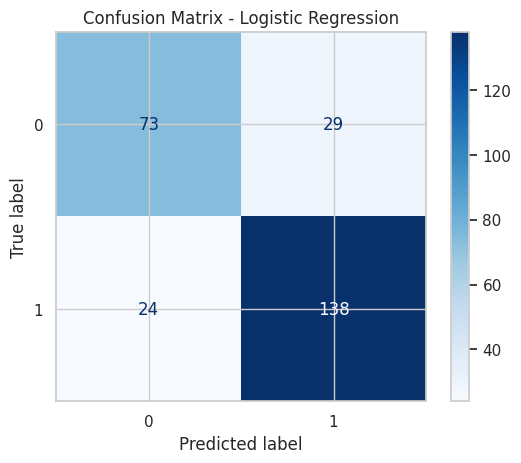

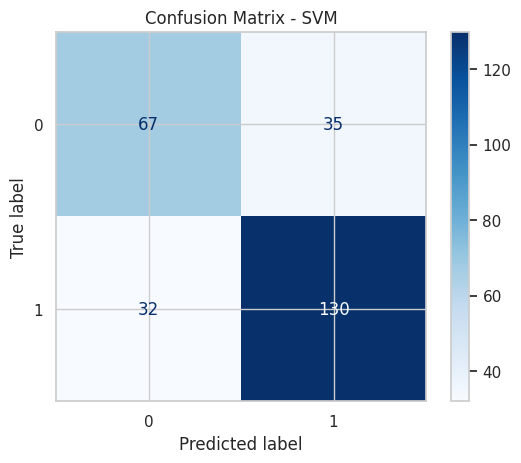

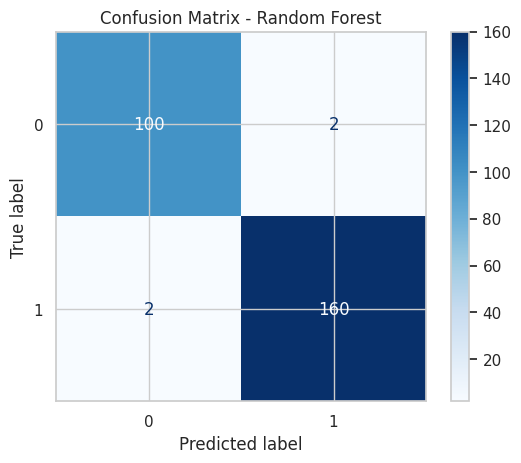

In [15]:
# ===============================
# CONFUSION MATRICES
# ===============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, (model, X_tr, X_te) in models.items():

    y_pred = model.predict(X_te)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.show()

## **Combined ROC Curve**

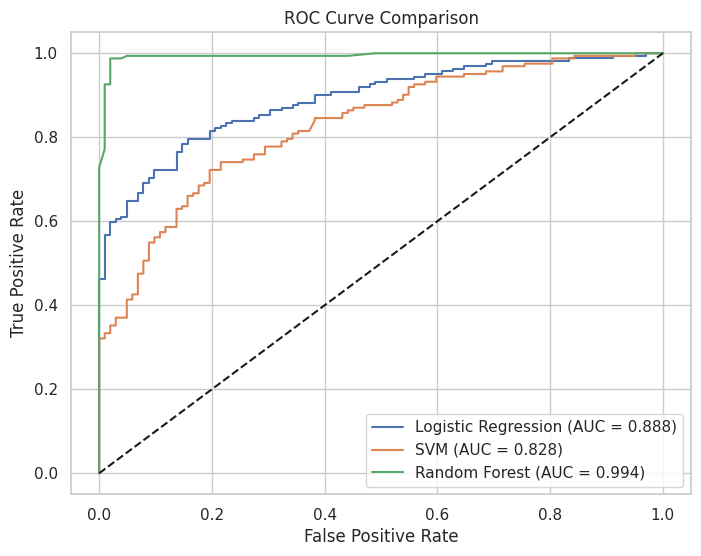

In [16]:
# ===============================
# ROC CURVES
# ===============================

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, (model, X_tr, X_te) in models.items():

    y_prob = model.predict_proba(X_te)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

# **Bayesian Hyperparameter Optimization**

In [17]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.5 MB/s eta 0:00:00


## **Training and Evaluating Models for Optimization**

[I 2026-04-21 20:33:03,029] A new study created in memory with name: no-name-5056f90e-9d64-4979-8f5f-623dccd57593
[I 2026-04-21 20:33:03,165] Trial 0 finished with value: 0.7925578132288432 and parameters: {'C': 1.2827886166872557}. Best is trial 0 with value: 0.7925578132288432.
[I 2026-04-21 20:33:03,286] Trial 1 finished with value: 0.8067015202135848 and parameters: {'C': 1.9022408737394065}. Best is trial 1 with value: 0.8067015202135848.
[I 2026-04-21 20:33:03,361] Trial 2 finished with value: 0.6639724014453077 and parameters: {'C': 0.01646513257988287}. Best is trial 1 with value: 0.8067015202135848.
[I 2026-04-21 20:33:03,591] Trial 3 finished with value: 0.7863512809798097 and parameters: {'C': 0.7893268424208651}. Best is trial 1 with value: 0.8067015202135848.
[I 2026-04-21 20:33:03,670] Trial 4 finished with value: 0.8078547228384847 and parameters: {'C': 2.5077465597109487}. Best is trial 4 with value: 0.8078547228384847.
[I 2026-04-21 20:33:03,718] Trial 5 finished with 


Best Logistic Regression Parameters:
{'C': 4.914938551921263}

Best SVM Parameters:
{'C': 7.098679864641088, 'kernel': 'linear', 'gamma': 'scale'}

Best Random Forest Parameters:
{'n_estimators': 293, 'max_depth': 3, 'min_samples_split': 5}


<Figure size 800x600 with 0 Axes>

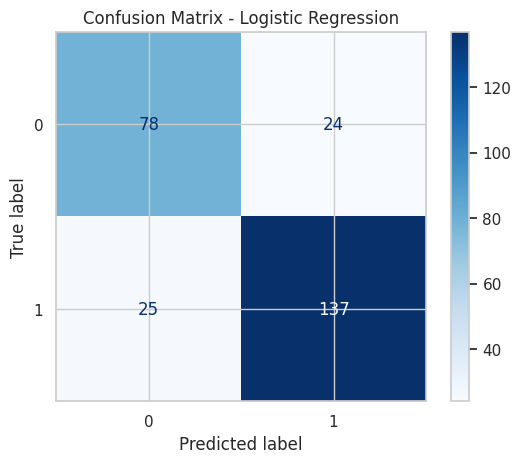

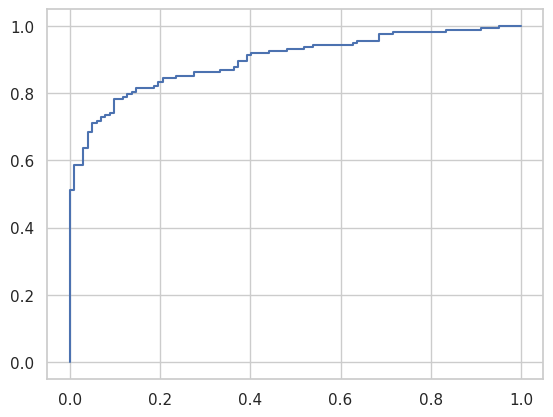

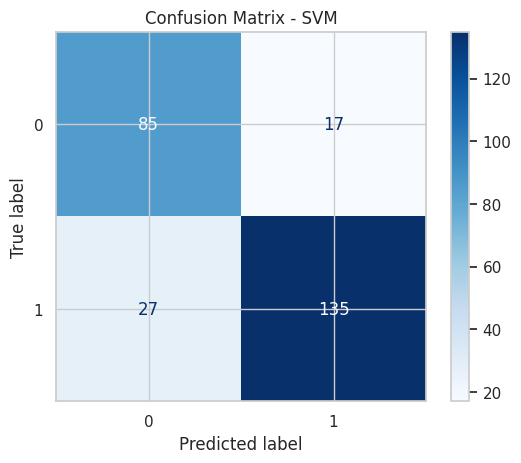

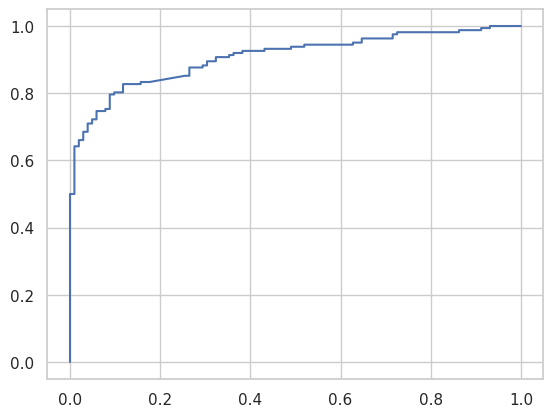

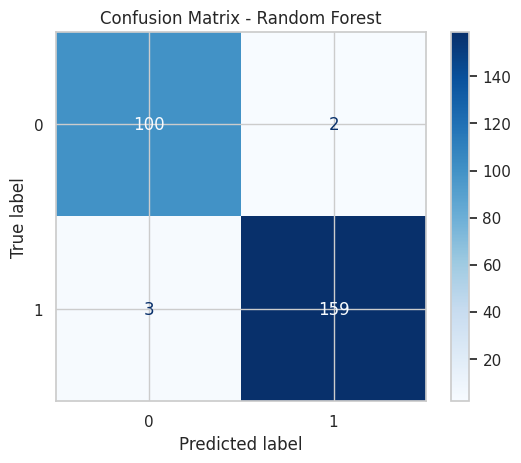

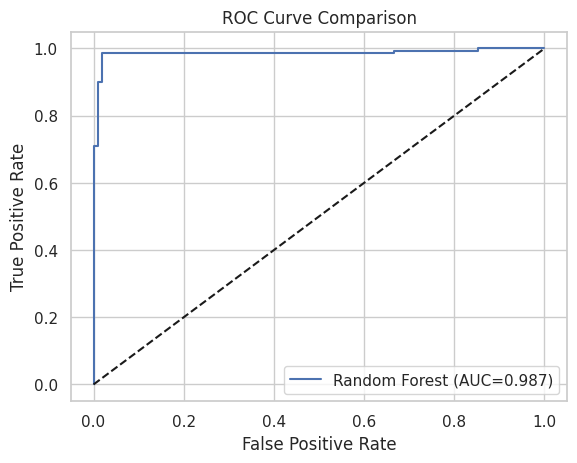


Model Performance Summary:

                 Model  Accuracy  Precision    Recall  F1 Score  \
2        Random Forest  0.981061   0.981124  0.981061  0.981077   
1                  SVM  0.833333   0.838228  0.833333  0.834573   
0  Logistic Regression  0.814394   0.814749  0.814394  0.814559   

   Train Time (s)  Test Time (s)  
2        0.584843       0.024904  
1        0.302543       0.003895  
0        0.011065       0.000456  


In [18]:
# ==========================================================
# OPTUNA HYPERPARAMETER OPTIMIZATION + FINAL MODEL EVALUATION
# ==========================================================

import optuna
import time
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc


# ===============================
# OPTUNA OBJECTIVE FUNCTIONS
# ===============================

def objective_lr(trial):

    C = trial.suggest_float("C", 1e-3, 10, log=True)

    model = LogisticRegression(C=C, max_iter=1000)

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="f1_weighted"
    ).mean()

    return score


def objective_svm(trial):

    C = trial.suggest_float("C", 0.1, 10)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    gamma = trial.suggest_categorical("gamma", ["scale", "auto"])

    model = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        probability=True
    )

    score = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="f1_weighted"
    ).mean()

    return score


def objective_rf(trial):

    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 3, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1_weighted"
    ).mean()

    return score


# ===============================
# RUN OPTUNA OPTIMIZATION
# ===============================

study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(objective_lr, n_trials=20)

study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=20)

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=20)


# ===============================
# PRINT BEST PARAMETERS
# ===============================

print("\nBest Logistic Regression Parameters:")
print(study_lr.best_params)

print("\nBest SVM Parameters:")
print(study_svm.best_params)

print("\nBest Random Forest Parameters:")
print(study_rf.best_params)


# ===============================
# CREATE BEST MODELS
# ===============================

best_lr = LogisticRegression(**study_lr.best_params, max_iter=1000)

best_svm = SVC(**study_svm.best_params, probability=True)

best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)


models = {
    "Logistic Regression": (best_lr, X_train_scaled, X_test_scaled),
    "SVM": (best_svm, X_train_scaled, X_test_scaled),
    "Random Forest": (best_rf, X_train, X_test)
}


# ===============================
# TRAIN MODELS + EVALUATION
# ===============================

results = []

plt.figure(figsize=(8,6))

for name, (model, Xtr, Xte) in models.items():

    # Train time
    start_train = time.time()
    model.fit(Xtr, y_train)
    end_train = time.time()

    train_time = end_train - start_train

    # Test time
    start_test = time.time()
    y_pred = model.predict(Xte)
    end_test = time.time()

    test_time = end_test - start_test

    y_prob = model.predict_proba(Xte)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, prec, rec, f1, train_time, test_time])


    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.show()


    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")


# ===============================
# ROC CURVE COMPARISON
# ===============================

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()


# ===============================
# SUMMARY TABLE
# ===============================

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Train Time (s)",
    "Test Time (s)"
])

print("\nModel Performance Summary:\n")

print(results_df.sort_values(by="F1 Score", ascending=False))

# **K-Fold Cross Validation**

In [19]:
# =====================================================
# K-FOLD CROSS VALIDATION WITH STANDARD DEVIATION
# =====================================================

import pandas as pd
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


# K-Fold Setup
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy','precision_weighted','recall_weighted','f1_weighted']

results = []

for name, model in models.items():

    # Use scaled data for LR and SVM
    if name == "Random Forest":
        X_data = X
    else:
        X_data = scaler.fit_transform(X)

    scores = cross_validate(
        model,
        X_data,
        y,
        cv=kfold,
        scoring=scoring
    )

    results.append([
        name,
        scores['test_accuracy'].mean(),
        scores['test_accuracy'].std(),
        scores['test_precision_weighted'].mean(),
        scores['test_precision_weighted'].std(),
        scores['test_recall_weighted'].mean(),
        scores['test_recall_weighted'].std(),
        scores['test_f1_weighted'].mean(),
        scores['test_f1_weighted'].std()
    ])


# Create Summary Table
cv_results = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy Mean",
    "Accuracy Std",
    "Precision Mean",
    "Precision Std",
    "Recall Mean",
    "Recall Std",
    "F1 Mean",
    "F1 Std"
])

print("\nK-Fold Cross Validation Results\n")

print(cv_results.sort_values(by="F1 Mean", ascending=False))


K-Fold Cross Validation Results

                 Model  Accuracy Mean  Accuracy Std  Precision Mean  \
2        Random Forest       0.984840      0.005351        0.985124   
0  Logistic Regression       0.792277      0.022175        0.794488   
1                  SVM       0.737703      0.018169        0.738325   

   Precision Std  Recall Mean  Recall Std   F1 Mean    F1 Std  
2       0.005310     0.984840    0.005351  0.984869  0.005342  
0       0.019751     0.792277    0.022175  0.792220  0.020559  
1       0.017012     0.737703    0.018169  0.736614  0.017985  


# **Model Explainability using SHAP**


SHAP Feature Importance (Global)



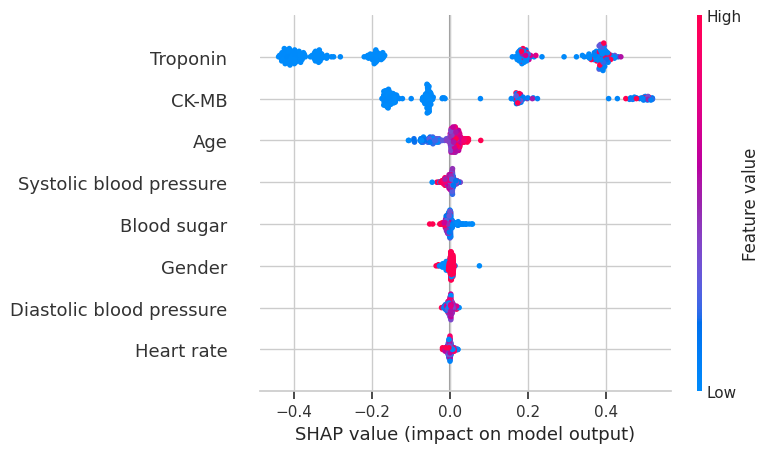

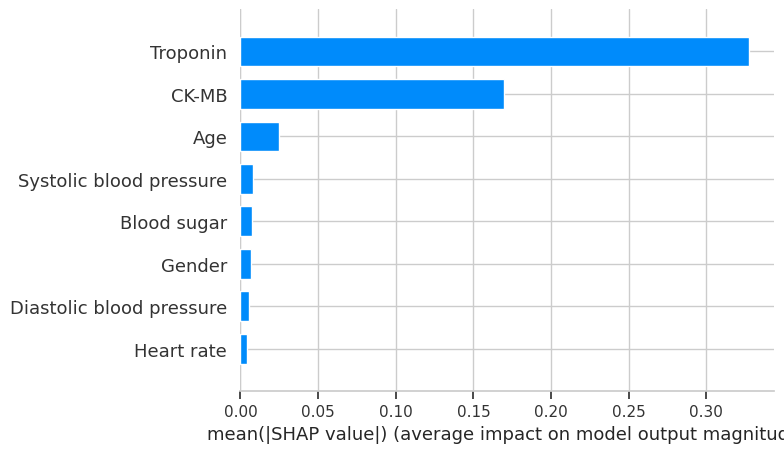

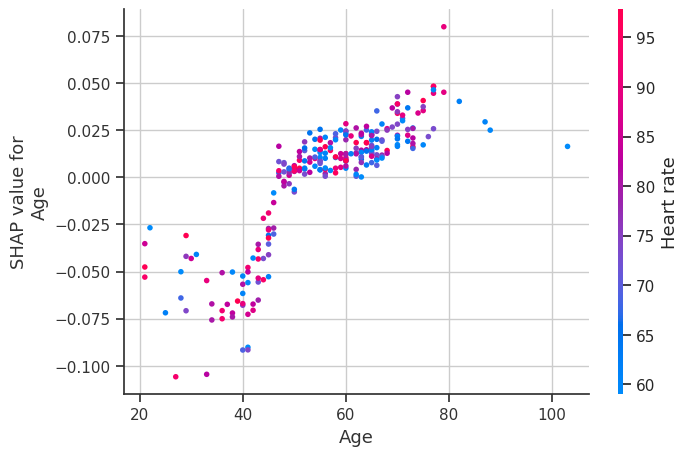

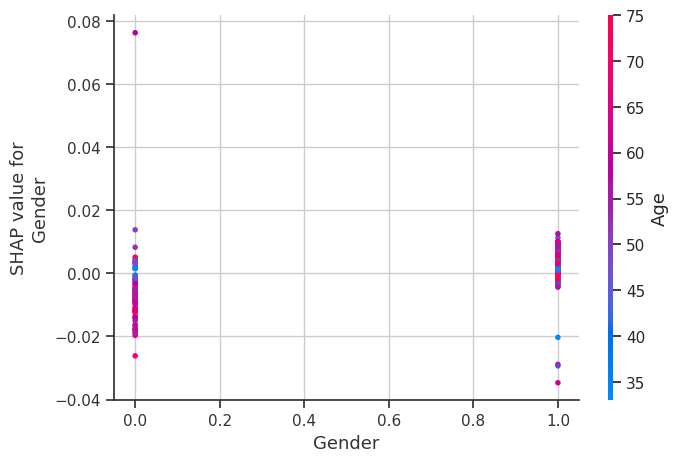

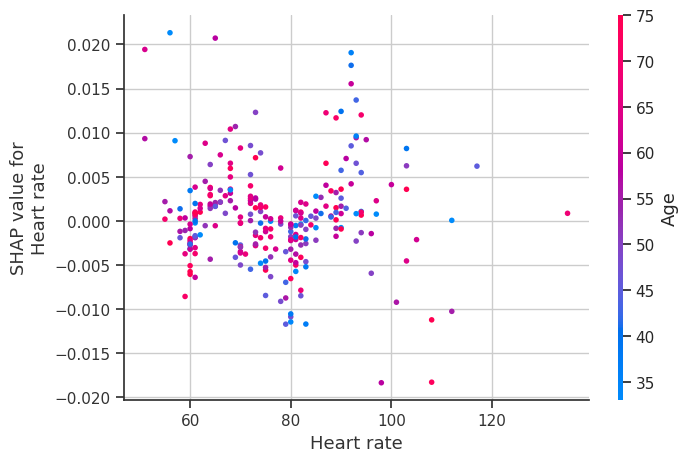

In [20]:
# =====================================================
# SHAP EXPLANATION FOR HEART DISEASE RISK FACTORS
# =====================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


# Train model (tree-based models work best with SHAP)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


# Initialize SHAP Tree Explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)


# ===============================
# GLOBAL FEATURE IMPORTANCE
# ===============================

print("\nSHAP Feature Importance (Global)\n")

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X.columns
)


# ===============================
# BAR PLOT OF MOST IMPORTANT FEATURES
# ===============================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X.columns,
    plot_type="bar"
)


# ===============================
# DEPENDENCE PLOTS FOR RISK FACTORS
# (Example: Cholesterol, Smoking)
# ===============================

important_features = X.columns[:3]   # change if needed

for feature in important_features:

    shap.dependence_plot(
        feature,
        shap_values[:, :, 1],
        X_test
    )


# ===============================
# FORCE PLOT (INDIVIDUAL PREDICTION)
# ===============================

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[:, :, 1][0],
    X_test.iloc[0]
)

# **Class Balancing using SMTOTE and ADASYN**


Data Balancing Comparison Results

                 Model Dataset Type  Accuracy  Precision  \
0  Logistic Regression     Original  0.799242   0.797845   
1                  SVM     Original  0.746212   0.744949   
2        Random Forest     Original  0.984848   0.984848   
3  Logistic Regression        SMOTE  0.772727   0.788972   
4                  SVM        SMOTE  0.738636   0.763206   
5        Random Forest        SMOTE  0.981061   0.981124   
6  Logistic Regression       ADASYN  0.776515   0.801022   
7                  SVM       ADASYN  0.742424   0.773615   
8        Random Forest       ADASYN  0.981061   0.981124   

   Recall (Sensitivity)  F1 Score  
0              0.799242  0.798246  
1              0.746212  0.745482  
2              0.984848  0.984848  
3              0.772727  0.775511  
4              0.738636  0.742055  
5              0.981061  0.981077  
6              0.776515  0.779438  
7              0.742424  0.745723  
8              0.981061  0.981077  


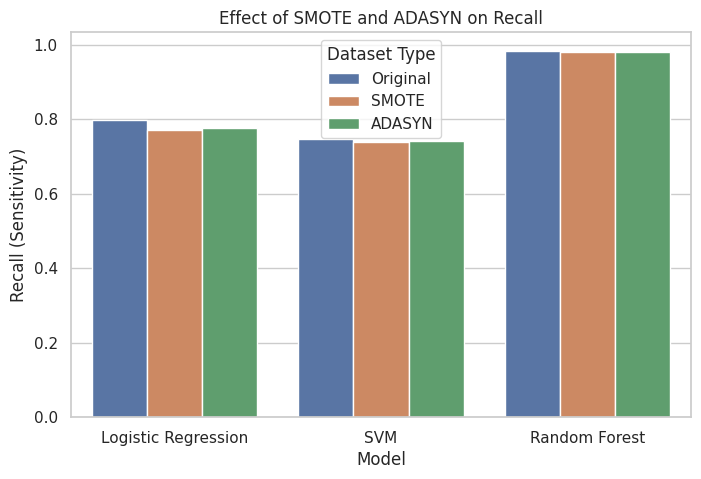

In [21]:
# ==========================================================
# DATA BALANCING COMPARISON (ORIGINAL vs SMOTE vs ADASYN)
# USING ALL MODELS
# ==========================================================

from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}


results = []


# =====================================================
# ORIGINAL DATASET
# =====================================================

for name, model in models.items():

    if name == "Random Forest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    results.append([
        name,
        "Original",
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,average='weighted'),
        recall_score(y_test,y_pred,average='weighted'),
        f1_score(y_test,y_pred,average='weighted')
    ])


# =====================================================
# SMOTE BALANCING
# =====================================================

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

scaler_smote = StandardScaler()
X_smote_scaled = scaler_smote.fit_transform(X_smote)
X_test_scaled2 = scaler_smote.transform(X_test)


for name, model in models.items():

    if name == "Random Forest":
        model.fit(X_smote, y_smote)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_smote_scaled, y_smote)
        y_pred = model.predict(X_test_scaled2)

    results.append([
        name,
        "SMOTE",
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,average='weighted'),
        recall_score(y_test,y_pred,average='weighted'),
        f1_score(y_test,y_pred,average='weighted')
    ])


# =====================================================
# ADASYN BALANCING
# =====================================================

adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

scaler_adasyn = StandardScaler()
X_adasyn_scaled = scaler_adasyn.fit_transform(X_adasyn)
X_test_scaled3 = scaler_adasyn.transform(X_test)


for name, model in models.items():

    if name == "Random Forest":
        model.fit(X_adasyn, y_adasyn)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_adasyn_scaled, y_adasyn)
        y_pred = model.predict(X_test_scaled3)

    results.append([
        name,
        "ADASYN",
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,average='weighted'),
        recall_score(y_test,y_pred,average='weighted'),
        f1_score(y_test,y_pred,average='weighted')
    ])


# =====================================================
# RESULTS TABLE
# =====================================================

results_df = pd.DataFrame(results, columns=[
    "Model",
    "Dataset Type",
    "Accuracy",
    "Precision",
    "Recall (Sensitivity)",
    "F1 Score"
])

print("\nData Balancing Comparison Results\n")

print(results_df)


# =====================================================
# VISUALIZATION (RECALL IMPROVEMENT)
# =====================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall (Sensitivity)",
    hue="Dataset Type"
)

plt.title("Effect of SMOTE and ADASYN on Recall")
plt.ylabel("Recall (Sensitivity)")
plt.show()